In [1]:
import pandas as pd
import string
from collections import Counter
import re
import numpy as np
import geopandas as gpd

import plotly.io as pio
pio.renderers.default = 'browser'
import nbformat; print(nbformat.__version__)  
%pip install --upgrade nbformat plotly
pio.renderers.default = 'iframe'

5.10.4
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Part 1:
Please load the entire dataset. In the following, assume that the variable “iau_id1” identifies unique institutions 
and that enrollments are estimated by the variable “students5_estimated”. There is no need to incorporate any 
additional data sources.

In [44]:
df_enrollment = pd.read_csv("./enrollments.csv", encoding = "utf8")
df_gdp = pd.read_csv("./Countries GDP 1960-2020.csv")



C:\Users\sikka\AppData\Local\Temp\ipykernel_21344\1518337853.py:1: DtypeWarning: Columns (0: latitude, 1: longitude) have mixed types. Specify dtype option on import or set low_memory=False.
  df_enrollment = pd.read_csv("./enrollments.csv", encoding = "utf8")


## Data Cleanup

In [46]:
df_enrollment.info()

<class 'pandas.DataFrame'>
RangeIndex: 161560 entries, 0 to 161559
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   country                 161560 non-null  str    
 1   countrycode             159698 non-null  str    
 2   region                  159698 non-null  str    
 3   incomegroup             159691 non-null  str    
 4   iau_id                  161553 non-null  str    
 5   iau_id1                 161553 non-null  str    
 6   eng_name                161553 non-null  str    
 7   orig_name               138446 non-null  str    
 8   foundedyr               161525 non-null  float64
 9   yrclosed                460 non-null     float64
 10  private01               161525 non-null  float64
 11  coordinates             138352 non-null  str    
 12  latitude                138352 non-null  object 
 13  longitude               138352 non-null  object 
 14  phd_granting            161525 

In [4]:
df_enrollment["year"] = df_enrollment["year"].astype("Int64")

In [5]:
missing_code = df_enrollment[(df_enrollment["country"].isna() == False) & (df_enrollment["countrycode"].isna())]["country"].unique()
codes = ["TWN","VAT","NCL","REU","MTQ","GUF","CUW" ]
cc_map = dict(zip(missing_code, codes))

In [6]:
df_enrollment["countrycode"] = df_enrollment["countrycode"].fillna(df_enrollment["country"].map(cc_map))

In [8]:
# clean up latitude/longitude/coordinates columns which have mixed types 
mask = pd.to_numeric(df_enrollment["latitude"], errors="coerce").isna()
print(f"Latitude-non_num_value_before: ", df_enrollment.loc[mask]["latitude"].unique())
mask = pd.to_numeric(df_enrollment["longitude"], errors="coerce").isna()
print("Longitude-non_num_value_before: ",df_enrollment.loc[mask]["longitude"].unique())
mask = pd.to_numeric(df_enrollment["coordinates"], errors="coerce").isna()
print("Coordinate-non_num_value_before: ",df_enrollment.loc[mask]["coordinates"].unique())

df_enrollment["latitude"] = pd.to_numeric(df_enrollment["latitude"], errors="coerce")
df_enrollment["longitude"] = pd.to_numeric(df_enrollment["longitude"], errors="coerce")
df_enrollment["coordinates"] = pd.to_numeric(df_enrollment["coordinates"], errors="coerce")
mask = pd.to_numeric(df_enrollment["latitude"], errors="coerce").isna()
print(f"Latitude-non_num_value_after: ", df_enrollment.loc[mask]["latitude"].unique())
mask = pd.to_numeric(df_enrollment["longitude"], errors="coerce").isna()
print("Longitude-non_num_value_after: ",df_enrollment.loc[mask]["longitude"].unique())
mask = pd.to_numeric(df_enrollment["coordinates"], errors="coerce").isna()
print("Coordinates-non_num_value_after: ",df_enrollment.loc[mask]["coordinates"].unique())


Latitude-non_num_value_before:  [nan
 'u-auben.org;recrutementisig@gmail.com+(U-Auben)+burkina+faso/@43.7824893'
 'https://www.google.com/maps/search/University+of+Ja%C3%A9n+spain'
 'https://www.google.com/maps/search/Business+University+of+Costa+Rica+costa%20rica'
 'https://www.google.com/maps/search/Jos%C3%A9+Mar%C3%ADa+Vargas+University+venezuela'
 'https://www.google.com/maps/search/University+of+Bath+united%20kingdom'
 'https://www.google.com/maps/search/University+of+Oxford+Corpus+Christi+College+united%20kingdom'
 '+Torrens+University/@-33.719429']
Longitude-non_num_value_before:  [nan ' https://www.google.com/maps/search/University+of+Ja%C3%A9n+spain'
 ' https://www.google.com/maps/search/Business+University+of+Costa+Rica+costa%20rica'
 ' https://www.google.com/maps/search/Jos%C3%A9+Mar%C3%ADa+Vargas+University+venezuela'
 ' https://www.google.com/maps/search/University+of+Bath+united%20kingdom'
 ' https://www.google.com/maps/search/University+of+Oxford+Corpus+Christi+College+u

# Part 2
What civil or geopolitical events do you think you might be able to detect with this data set? Create one or more 
visualizations and some basic analysis to make some initial observations about this event as it impacted 
university enrollments. It is ok if the event turns out not to be observable in the data. 

## Data exploration

In [33]:
# Try checking unusual enrollment change across countries and times

cy = df_enrollment.groupby(["countrycode","year"])["students5_estimated"].sum().rename("enr").reset_index()
cy["pct_change"] = cy.groupby("countrycode")["enr"].pct_change()
# Created a new column to capture the case where the enrollment is 0, which we can later filter to see what's going on here
cy["zero_enr"] = cy["enr"] == 0
# Replace np.inf (which happens when the previous month enrollment is 0) with np.nan to avoid distorting percent change calculations.
cy["pct_change"] = cy["pct_change"].replace(np.inf, np.nan)
# Get mean and std of pct_change for each country in order to find out what is unusual amount of change
cms = cy.groupby("countrycode")["pct_change"].agg(["mean", "std"])
cy = cy.join(cms, on = "countrycode")
cy["z"] =(cy["pct_change"] - cy["mean"])/cy["std"]
cy['absz'] = cy['z'].abs()
#Identify the most anomalous year for each country, then select the top 12 countries with the largest anomalies.
abnormal_idx = cy.dropna(subset=["absz"]).groupby("countrycode")["absz"].idxmax()
top10_abnormal = cy.loc[abnormal_idx].sort_values(by = "absz", ascending = False).head(10)
top10_abnormal 



,countrycode,year,enr,pct_change,zero_enr,mean,std,z,absz
2003,SAU,1955,5383.0,896.166667,False,64.526165,239.362764,3.474394,3.474394
2480,VAT,1955,6080.0,84.633803,False,6.134677,22.594288,3.474291,3.474291
2018,SDN,1955,811.0,134.166667,False,10.243127,35.670134,3.474154,3.474154
715,ETH,1960,2420.0,39.333333,False,3.515973,10.325600,3.468792,3.468792
1546,MMR,1975,667721.0,18.453473,False,1.534333,4.885602,3.463061,3.463061
1200,KEN,1960,4305.0,15.494253,False,1.638996,4.003472,3.460810,3.460810
1230,KHM,1960,1669.0,24.676923,False,2.290530,6.469494,3.460300,3.460300
2167,SVK,1955,37377.0,4.972675,False,0.489272,1.296631,3.457733,3.457733
2451,USA,1960,4653250.0,1.367294,False,0.166084,0.347541,3.456313,3.456313
2301,TKM,1960,3362.0,10.796491,False,1.030394,2.839056,3.439911,3.439911


In [13]:
import plotly.express as px
d = cy.dropna(subset=['year', 'z']).copy()
d['year'] = d['year'].astype(int)
d = d.sort_values('year')
fig = px.choropleth(d, locations='countrycode', locationmode='ISO-3',
                    color='z', color_continuous_scale='RdBu_r',
                    color_continuous_midpoint=0, range_color=(-3, 3),
                    animation_frame='year')
fig.show()

### Topic & Hypothesis:
After 1990, a large number of East Germans moved to the West, known as Ost-West-Wanderung, which continued through the 1990s and 2000s. This migration may have left a detectable trace in university enrollment.

In [14]:
df_enr = df_enrollment.drop(["students5_interpolated","students5_extrapolated"], axis = 1)

In [15]:
# Get Germany data
df_deu = df_enr[df_enr["countrycode"] =="DEU"]

In [16]:
de = df_deu.drop(["country", "countrycode","region"], axis = 1)
de.head()

,incomegroup,iau_id,iau_id1,eng_name,orig_name,foundedyr,yrclosed,private01,coordinates,latitude,...,m_granting,b_granting,divisions,total_fields,unique_fields,specialized,merger,noiau,year,students5_estimated
249,High income,GLUE-263,GLUE-263-1,College Of Economy 'Bruno Leuschner' Berlin,NaN,1950.0,1991.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1970,1268.0
250,High income,GLUE-263,GLUE-263-1,College Of Economy 'Bruno Leuschner' Berlin,NaN,1950.0,1991.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1965,1584.0
251,High income,GLUE-263,GLUE-263-1,College Of Economy 'Bruno Leuschner' Berlin,NaN,1950.0,1991.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1990,2128.0
252,High income,GLUE-263,GLUE-263-1,College Of Economy 'Bruno Leuschner' Berlin,NaN,1950.0,1991.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1975,2368.0
253,High income,GLUE-263,GLUE-263-1,College Of Economy 'Bruno Leuschner' Berlin,NaN,1950.0,1991.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1985,2507.0


### Determine the border of West vs. East Germany

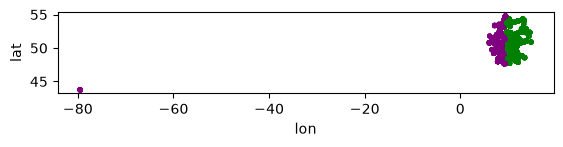

In [18]:
import matplotlib.pyplot as plt
# Initially, I used the median value of longitude to determine the border. However, the actual border is not straight
de['side'] = np.where(de['longitude'] > de.longitude.median(), 'East', 'West')
colors = de["side"].map({
    "East": "green",
    "West": "purple"
})
plt.scatter(de['longitude'], de['latitude'], c=(colors), s=8)
plt.xlabel('lon'); plt.ylabel('lat'); plt.gca().set_aspect(1.4)
plt.show()

In [19]:
# In order to capture the border, I collected the coordinates of university towns near the inner German border to test
anchors = {  # (lon, lat, expected)
    "Goettingen": (9.94, 51.54, 'West'), 
    "Marburg": (8.77, 50.81, 'West'),
    "Bayreuth": (11.58, 49.95, 'West'),  # This city belonged to West Germany but was located more to the east
    "Bamberg": (10.89, 49.89, 'West'),
    "Wuerzburg": (9.95, 49.79, 'West'),  
    "Hof": (11.91, 50.31, 'West'), # This city belonged to West Germany but was located more to the east
    "Jena": (11.59, 50.93, 'East'),      
    "Halle": (11.97, 51.48, 'East'),
    "Leipzig": (12.37, 51.34, 'East'),   
    "Erfurt": (11.03, 50.98, 'East'),
    "Ilmenau": (10.91, 50.68, 'East'),
    
}

In [20]:
def side(lon, lat, lon_cut=de.longitude.median(),):
    return 'East' if (lon > lon_cut) else 'West'

for city,(lon,lat, true_side) in anchors.items():
    pred_side = side(lon,lat)
    print(f"{'OK ' if pred_side==true_side else 'MISS'} {city:12} true {true_side} pred {pred_side}")

# Almost half of the border-region is missed, so we need a different approach.

MISS Goettingen   true West pred East
OK  Marburg      true West pred West
MISS Bayreuth     true West pred East
MISS Bamberg      true West pred East
MISS Wuerzburg    true West pred East
MISS Hof          true West pred East
OK  Jena         true East pred East
OK  Halle        true East pred East
OK  Leipzig      true East pred East
OK  Erfurt       true East pred East
OK  Ilmenau      true East pred East


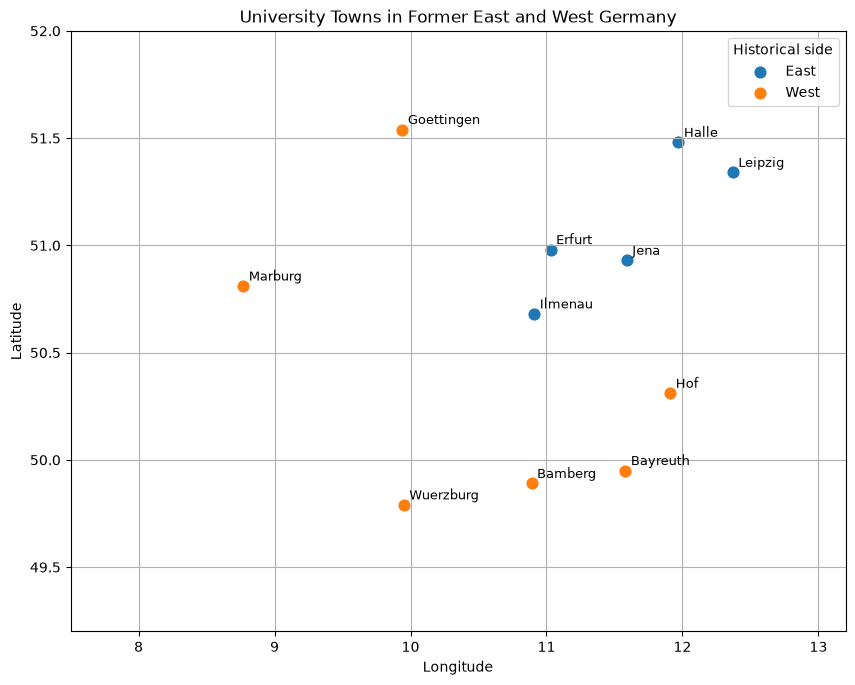

In [34]:
# Plot the cities on a longitude and latitude grid
df = pd.DataFrame([{"city": city, "longitude": longitude,"latitude": latitude,"side": side,} for city, (longitude, latitude, side) in anchors.items()])
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(10, 10))

for side, group in gdf.groupby("side"):
    group.plot(
        ax=ax,
        marker="o",
        markersize=60,
        label=side,
    )

for _, row in gdf.iterrows():
    ax.annotate(
        row["city"],
        xy=(row["longitude"], row["latitude"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlim(7.5, 13.2)
ax.set_ylim(49.2, 52.0)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("University Towns in Former East and West Germany")
ax.legend(title="Historical side")
ax.grid(True)

plt.show()

In [35]:
def side(lon, lat, lon_cut=10.90, lat_floor=50.5):
    return 'East' if (lon > lon_cut and lat > lat_floor) else 'West'

for city,(lon,lat, true_side) in anchors.items():
    pred_side = side(lon,lat)
    print(f"{'OK ' if pred_side==true_side else 'MISS'} {city:12} true {true_side} pred {pred_side}")

OK  Goettingen   true West pred West
OK  Marburg      true West pred West
OK  Bayreuth     true West pred West
OK  Bamberg      true West pred West
OK  Wuerzburg    true West pred West
OK  Hof          true West pred West
OK  Jena         true East pred East
OK  Halle        true East pred East
OK  Leipzig      true East pred East
OK  Erfurt       true East pred East
OK  Ilmenau      true East pred East


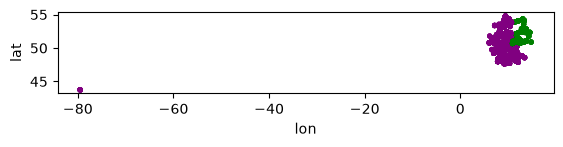

In [36]:
# Add a column that marks whether the institution belongs to West or East

de["side"] = de.apply(
    lambda row: side(row["longitude"], row["latitude"]),
    axis=1
)
colors = de["side"].map({
    "East": "green",
    "West": "purple"
})

plt.scatter(de['longitude'], de['latitude'], c=(colors), s=8)
plt.xlabel('lon'); plt.ylabel('lat'); plt.gca().set_aspect(1.4)
plt.show()


### 1. Check whether the enrollment growth rate increased after 1990 in the West while it decreased in the East: 
After 1990, large numbers of East Germans moved west, a migration that continued through the 1990s and 2000s. If this impacted higher education, it would plausibly show up as East institutions losing enrollment relative to the West, and/or West institutions gaining.

In [37]:
# I wanted to analyze the growth rates after reunification.
# To do this, I standardized the growth rates within each region using z-scores.

old_de =de.groupby(['side','year'])['students5_estimated'].sum().rename("enr").reset_index()
old_de["pct_change"] = old_de.groupby("side")["enr"].pct_change()
side_mean_std = old_de.groupby("side")["pct_change"].agg(["mean","std"])
old_de = old_de.join(side_mean_std, on ="side")
old_de["z"] = (old_de["pct_change"] - old_de["mean"])/old_de["std"]
old_de["absz"] = old_de["z"].abs()

old_de.pivot(
    index='year', columns='side', values='z')

# Post-reunification, I observed the opposite trend from what I initially hypothesized.
# This could be, however, due to the nature of how the z-score is calculated.

side,East,West
year,,
1950,NaN,NaN
1955,-0.554419,0.518569
1960,0.202996,0.884973
1965,0.798977,0.144567
1970,-0.780430,-0.063534
1975,1.132027,2.791960
1980,-0.075007,0.468970
1985,0.370857,0.130406
1990,0.144190,-0.333624


In [38]:
# West Germany experienced a very high growth rate in university enrollment in 1975,
# which could be driven by the baby boom generation reaching the age of entering university
# and/or could be the result of the government's investment in higher education during this time.

# Because the z-score is calculated using the mean and standard deviation of the entire time series,
# this earlier surge influences the baseline and may make the later increase appear less pronounced
# For this reason, instead of using z-scores, I anchored the baseline to 1990, when reunification happened, 
# and investigated the ratio of raw enrollment against the baseline
# in order to minimize the impact of the enrollment counts of other years 
# This will allow us to compare each year's enrollment with the year of reunification

old_de = de.groupby(['side','year'])['students5_estimated'].sum().rename('enr').reset_index()
base = old_de[old_de['year']==1990].set_index('side')['enr']
old_de["idx"] = old_de.apply(lambda r: round(((r["enr"]/base[r['side']])*100)- 100, 2), axis = 1)
# print(old_de)*
old_de_index = old_de.pivot_table(index = "year", columns = "side", values = "idx")
old_de_index["Growth_Diff(West - East)"] = old_de_index["West"] - old_de_index["East"]
old_de_index.loc[old_de_index.index>= 1990]


side,East,West,Growth_Diff(West - East)
year,,,
1990,0.00,0.00,0.00
1995,40.49,14.99,-25.50
2000,51.29,21.88,-29.41
2005,71.74,27.34,-44.40
2010,87.25,41.68,-45.57
2015,101.86,57.99,-43.87
2020,108.22,80.93,-27.29


In [26]:
# Post reunification enrollment growth analysis:
# The highly negative 'Growth_Diff' values (e.g., -24.75 in 1995) mathematically prove that 
# the East experienced a far higher enrollment growth rate than the West.
# The migration-driven enrollment decline in the East that I expected is not visible in this channel.

# This directly contradicts my initial expectation that the historic East-to-West migration 
# (Ost-West-Wanderung) would boost Western enrollment at the expense of the East.

# This pattern is, however, broadly consistent with the historical period following German reunification.
# Under the former East German education system, access to higher education was more tightly controlled.
# After reunification,
# the expansion of educational opportunities in the East may have allowed more high school (Gymnasium) graduates to continue to university
# and allowed the backlog of older Gymnasium graduates to enroll in university, contributing to the higher-than-usual growth rate.
# In contrast, the West shows much slower growth than the East.
# One possible explanation is the increase in broadened access/democratization after reunification. 
# This process rebuilt infrastructure and installed prominent West German scholars to lead the newly democratized faculties. 
# This may have incentivized East German Gymnasium students to remain in the East

count_institution = de.drop_duplicates(subset = "iau_id1").groupby(["side", "foundedyr"])["iau_id1"].size().rename("#_institution").reset_index()
count_institution[(count_institution["foundedyr"]>1989) & (count_institution["foundedyr"]< 2001)].pivot_table(index = "foundedyr", columns = "side", values = "#_institution")

# The table listing the number of universities founded each year is incomplete.
# However, it indicates that more universities were established in East Germany than in West Germany in 1991 and 1992.
# Although this data is suggestive, the interpretation cannot really be confirmed from the enrollment data alone.
# Adding regional secondary-school (Gymnasium) enrollment, population by age/region, or enrollment-by-origin to the data 
# will help to confirm the direct impact of migration on university enrollment.

# Importantly, a lower growth rate does not imply the decline of actual enrollment. It just indicates that enrollment is growing slower than usual.
# The East started from a smaller base, so "faster growth than the West" is compatible with the East still being far smaller in absolute students the whole time.
# For this reason, I next examine the raw enrollment counts, which can tell
# whether East's faster rate actually translated into meaningful numbers, or whether it's a big percentage on a small base.


side,East,West
foundedyr,,
1990.0,NaN,3.0
1991.0,11.0,3.0
1992.0,7.0,3.0
1993.0,NaN,3.0
1994.0,1.0,8.0
1995.0,NaN,3.0
1996.0,NaN,7.0
1997.0,NaN,3.0
1998.0,1.0,2.0


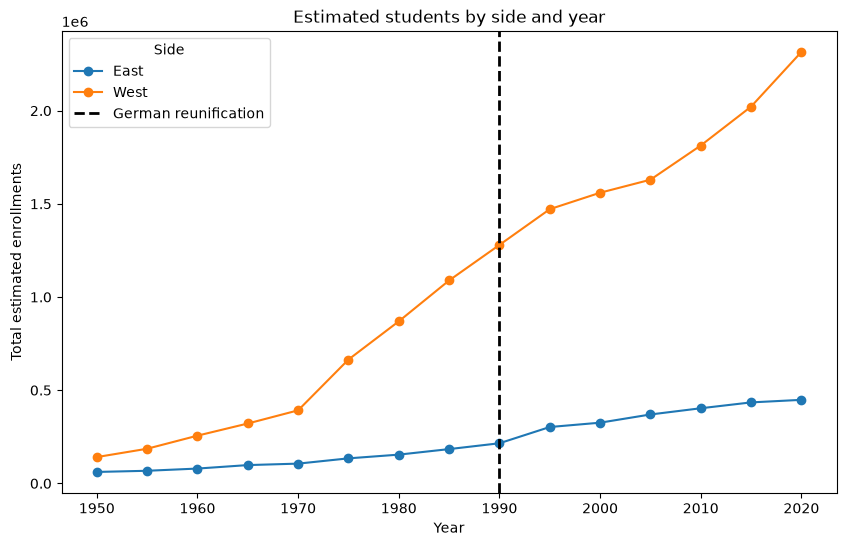

In [40]:

de.groupby(["side","year"])["students5_estimated"].sum()
grouped = de.groupby(["side", "year"])["students5_estimated"].sum().unstack("side")
grouped.plot(kind="line", marker="o",figsize=(10, 6))

plt.axvline(x=1990, color="black", linestyle="--", linewidth=2,label="German reunification")
plt.xlabel("Year")
plt.ylabel("Total estimated enrollments")
plt.title("Estimated students by side and year")
plt.legend(title="Side")
plt.show()


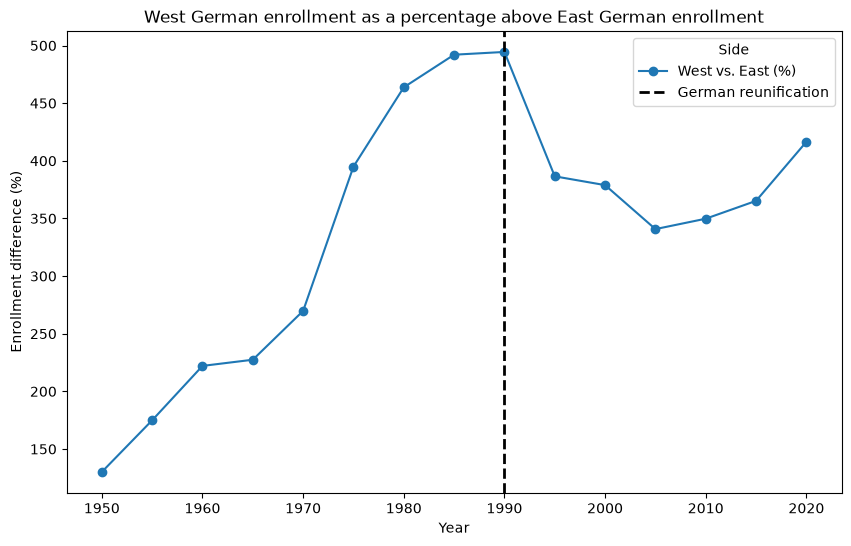

In [41]:
# Compare the raw enrollment between East and West
grouped = de.groupby(["side", "year"])["students5_estimated"].sum().rename("enr").reset_index()
enr_year_diff = grouped.pivot_table(index = "year", columns = "side", values = "enr")

enr_year_diff["West_vs_East"] = round(((enr_year_diff["West"] - enr_year_diff["East"])/enr_year_diff["East"])*100, 2)

enr_year_diff["West_vs_East"].plot(kind="line", marker="o", figsize=(10, 6), label="West vs. East (%)")
plt.axvline(x=1990, color="black", linestyle="--", linewidth=2,label="German reunification")
plt.xlabel("Year")
plt.ylabel("Enrollment difference (%)")
plt.title("West German enrollment as a percentage above East German enrollment")
plt.legend(title="Side")
plt.show()

# West has more students in absolute terms throughout,
# but the gap narrows after 1990 as the East grows, so the faster East rate from the index is real growth, not just a small-base artifact.

### To summarize, 
the enrollment data does not show evidence that post-reunification migration 
from East to West left a traceable impact where Western enrollment increased while Eastern enrollment dipped.
On the contrary, the increased growth observed in the East post-reunification could actually be driven 
by government efforts to westernize and democratize education following the fall of the socialist regime,
which likely boosted enrollment across the Eastern region.
However, we did observe a continuous increase in university enrollment on the Western side, 
though the precise driving force behind that trend remains unclear from this metric alone.

If I continue this research into the potential impact of migration on enrollment in the West:
- I would collect regional lower-level education enrollment and regional population data, ideally at 
the student level, which would allow us to directly track student mobility and migration patterns.
- Moreover, the East/West split is currently approximated using geographic coordinates, which introduces 
the risk of misclassifying institutions near regional borders, so I would like to implement a more robust classification method.

# Part 3

Your client wants to know how GDP is related to university enrollment. Join the provided data set “Countries 
GDP 1960-2020.csv” onto the enrollments one and briefly describe the relationship you see.

In [29]:
#Merge the enrollment data with GDP data
df_gdp.head()
gdp_unpivot = (pd.melt(df_gdp.drop("Country Name", axis = 1), id_vars = "Country Code", var_name = "year", value_name = "GDP")
    .rename(columns = {"Country Code":"countrycode"}))
gdp_unpivot["year"] = gdp_unpivot["year"].astype("Int64")
df_enr_gdp = df_enrollment.merge(gdp_unpivot, on = ["countrycode", "year"], how = "left")
# Drop the rows that do not have GDP and enrollment estimates
df_enr_gdp_filtered = df_enr_gdp.dropna(subset = ["GDP", "students5_estimated"])

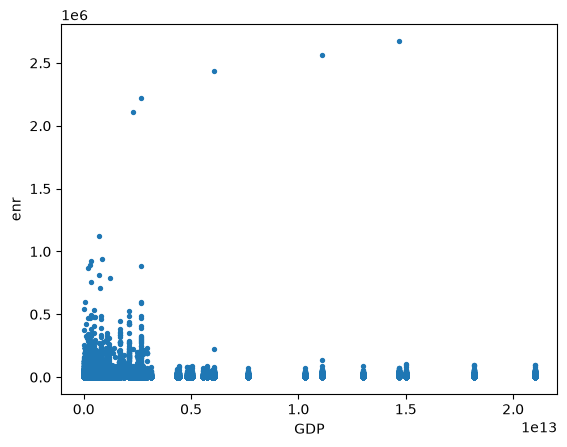

In [30]:
plt.scatter(df_enr_gdp_filtered['GDP'], df_enr_gdp_filtered['students5_estimated'],  s=8)
plt.xlabel('GDP'); plt.ylabel('enr')
plt.show()

# Based on the scatter plot below, there is no clear relationship between
# GDP and university enrollment when time is not taken into account.
# This may be because the relationship between GDP and enrollments can be different depending on the time.
# For instance, at some point in history, education level may not have affected GDP, 
# like the era when no school system existed but people still did economic activity

In [31]:
# In order to capture the relation, the time information has to be included

g_y = df_enr_gdp_filtered.groupby("year")[['GDP','students5_estimated']].sum()
g_y[["GDP","students5_estimated"]].corr()

# The result shows a very high linear relationship. 
# Over time, GDP could have naturally grown, perhaps due to inflation.
# The population has also grown, potentially due to the development of medicine, 
# which may have provided a bigger pool of university enrollment candidates. 
# That is, this very high linear relationship could be due to other factors associated with long-term trends, 
# and does not necessarily show a direct relationship between GDP and enrollments.

,GDP,students5_estimated
GDP,1.000000,0.997272
students5_estimated,0.997272,1.000000


In [32]:
# For this reason, instead of looking at the raw data, we can use the growth rate.
# If we can confirm that the acceleration or decrease of the GDP growth rate is related to the growth rate of enrollment,
# it can isolate their relationship from other factors that may have influenced them over time.

df_enr_gdp_filtered = df_enr_gdp_filtered.sort_values(by = "year", ascending = True)
gdp_enr_y = df_enr_gdp_filtered.groupby("year").agg(GDP = ("GDP", "sum"), enr = ("students5_estimated", "sum"))
#gdp_y["pct_change"] = enr_gdp_y["GDP"].pct_change()
gdp_enr_y["GDP_pct_change"] = gdp_enr_y["GDP"].pct_change()
gdp_enr_y["enr_pct_change"] = gdp_enr_y["enr"].pct_change()
filtered = gdp_enr_y.dropna(subset = "GDP_pct_change")
filtered[["GDP_pct_change", "enr_pct_change"]].corr()

# The 0.67 correlation proves a robust, positive linear relationship between economic acceleration 
# and educational expansion.

,GDP_pct_change,enr_pct_change
GDP_pct_change,1.000000,0.665531
enr_pct_change,0.665531,1.000000
